# Fake News Detect Model 


In [1]:
#!pip install textacy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

In [2]:
df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')



print(df_fake.shape)
print(df_true.shape)

#add labels to the dataframes
df_fake['label'] = 0
df_true['label'] = 1

#concatenate the dataframes 
df = pd.concat([df_fake, df_true], axis=0)

print ("concatenated shape:", df.shape)

(23481, 4)
(21417, 4)
concatenated shape: (44898, 5)


## EDA

In [3]:
df.head(10)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [4]:
df.tail(10)

,title,text,subject,date,label
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [5]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [6]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [7]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [8]:
# it is normal to have duplicated title , date and subject 
print(df['text'].duplicated().sum())

#remove duplicates 
df.drop_duplicates(subset=['text'], inplace=True, keep='first')

print(df.shape)
df.describe(include='all')

6252
(38646, 5)


,title,text,subject,date,label
count,38646,38646,38646,38646,38646.000000
unique,38270,38646,7,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,politicsNews,"December 6, 2017",NaN
freq,14,1,11213,166,NaN
mean,NaN,NaN,NaN,NaN,0.548336
std,NaN,NaN,NaN,NaN,0.497665
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,1.000000
75%,NaN,NaN,NaN,NaN,1.000000


### visualization for the distribution 

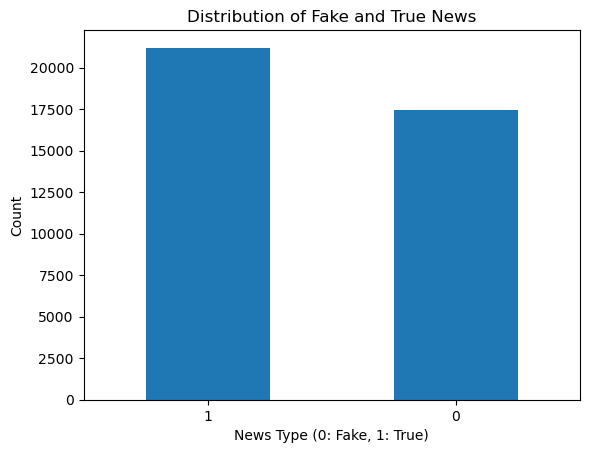

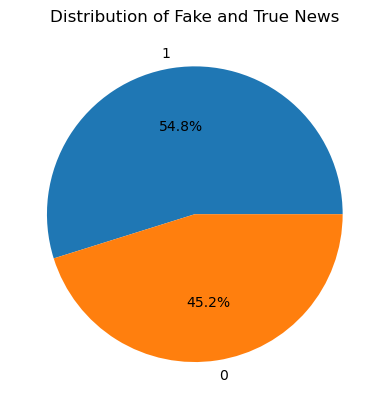

In [9]:
# Data Visualization (Distribution false / true news):
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Fake and True News')
plt.xlabel('News Type (0: Fake, 1: True)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Fake and True News')
plt.ylabel('')
plt.show()

In [10]:
# ratio of true news to fake news
fake_news_count = df['label'].value_counts()[0]
true_news_count = df['label'].value_counts()[1]
ratio = true_news_count / fake_news_count
print(f"Ratio of True News to Fake News: {ratio:.2f}")
print(f"for every 1 fake news there are {ratio:.2f} true news")

Ratio of True News to Fake News: 1.21
for every 1 fake news there are 1.21 true news


In [11]:
# text, title length distribution :
df['text_length'] = df['text'].apply(len)
df['title_length'] = df['title'].apply(len)

# Statistical summary by label (ham vs spam)
length_stats_by_label = df.groupby('label')['text_length'].describe()

print("Text length summary by label:")
print(length_stats_by_label)

# Optional: compare central tendency and spread directly
print("\nKey stats (mean, median, std) by label:")
print(
    df.groupby('label')['text_length']
      .agg(['mean', 'median', 'std', 'min', 'max'])
)

print("####################################################################")
# Statistical summary by label (ham vs spam)
length_stats_by_label = df.groupby('label')['title_length'].describe()

print("Title length summary by label:")
print(length_stats_by_label)

# Optional: compare central tendency and spread directly
print("\nKey stats (mean, median, std) by label:")
print(
    df.groupby('label')['title_length']
      .agg(['mean', 'median', 'std', 'min', 'max'])
)



Text length summary by label:
         count         mean          std    min     25%     50%     75%  \
label                                                                     
0      17455.0  2549.806989  2201.328315    1.0  1648.5  2235.0  3005.5   
1      21191.0  2378.527158  1683.781664  152.0   906.5  2216.0  3226.5   

           max  
label           
0      51794.0  
1      29781.0  

Key stats (mean, median, std) by label:
              mean  median          std  min    max
label                                              
0      2549.806989  2235.0  2201.328315    1  51794
1      2378.527158  2216.0  1683.781664  152  29781
####################################################################
Title length summary by label:
         count       mean        std   min   25%   50%    75%    max
label                                                               
0      17455.0  91.215812  24.516454   8.0  77.0  88.0  100.0  286.0
1      21191.0  64.660233   9.159722  26.0  5

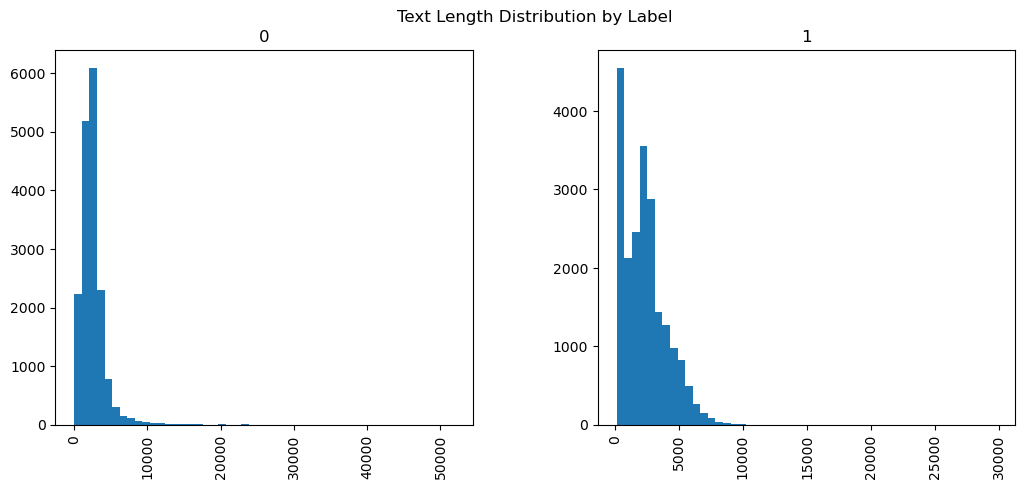

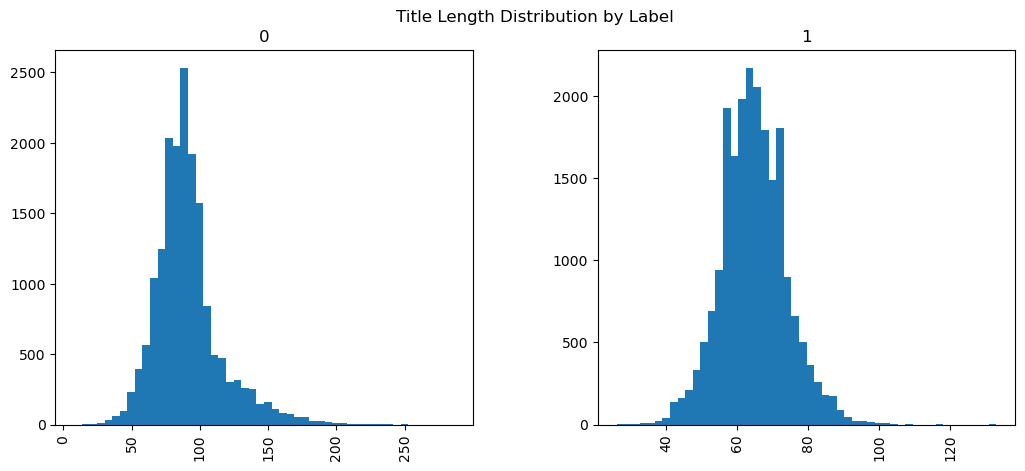

In [12]:
# Visualize text length distribution by label
df.hist(column='text_length', by='label', bins=50, figsize=(12, 5))
plt.suptitle('Text Length Distribution by Label')
plt.show()
# Visualize title length distribution by label
df.hist(column='title_length', by='label', bins=50, figsize=(12, 5))
plt.suptitle('Title Length Distribution by Label')
plt.show()

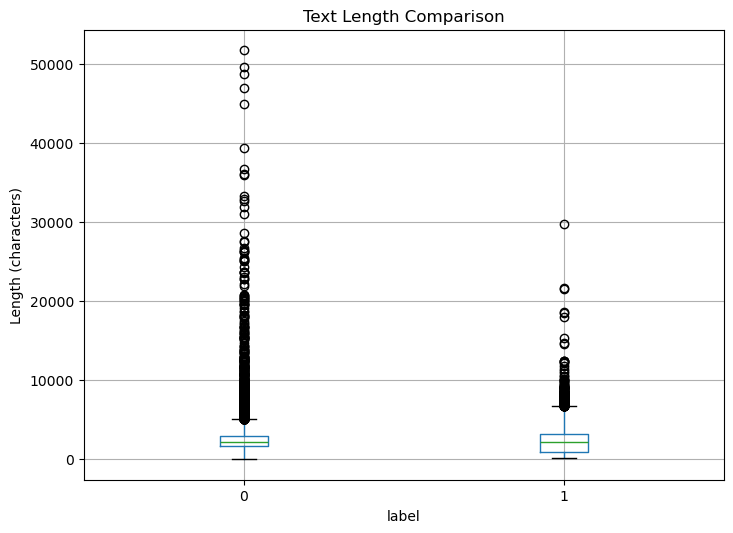

In [13]:
df.boxplot(column='text_length', by='label', figsize=(8, 6))
plt.title('Text Length Comparison')
plt.suptitle('')  # Remove default title
plt.ylabel('Length (characters)')
plt.show()

In [14]:
def count_outliers_by_label(df, column, label_col='label'):
    outlier_counts = {}
    for label in df[label_col].unique():
        group = df[df[label_col] == label]
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = group[(group[column] < lower) | (group[column] > upper)].shape[0]
        outlier_counts[label] = outlier_count
    return outlier_counts

# Example usage:
text_outliers_by_label = count_outliers_by_label(df, 'text_length')
title_outliers_by_label = count_outliers_by_label(df, 'title_length')

print("Text length outliers:", text_outliers_by_label)
print("Title length outliers:", title_outliers_by_label)

Text length outliers: {np.int64(0): 926, np.int64(1): 324}
Title length outliers: {np.int64(0): 1218, np.int64(1): 499}


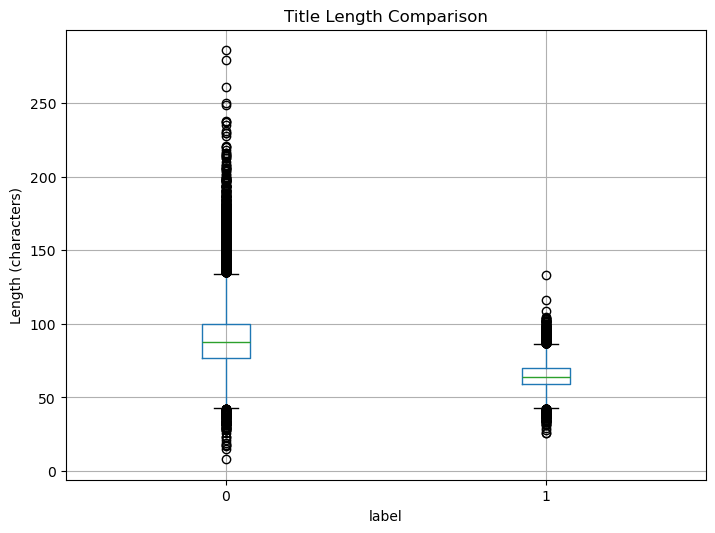

In [15]:
df.boxplot(column='title_length', by='label', figsize=(8, 6))
plt.title('Title Length Comparison')
plt.suptitle('')  # Remove default title
plt.ylabel('Length (characters)')
plt.show()

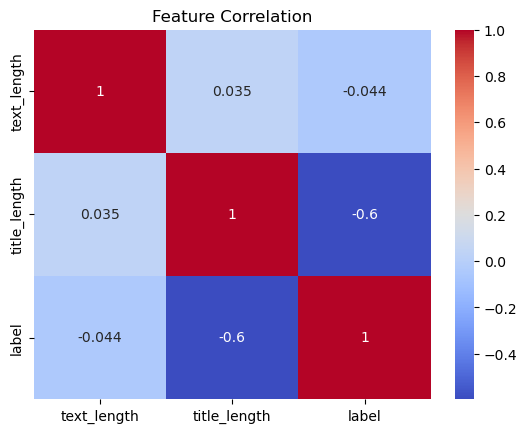

In [16]:
corr = df[['text_length', 'title_length', 'label']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# Preprocess

In [17]:
!pip install --upgrade pip setuptools wheel
!pip install spacy textacy --only-binary :all:

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached wheel-0.46.3-py3-none-any.whl (30 kB)


ERROR: To modify pip, please run the following command:
C:\Users\HP\miniconda3\envs\nxx86\python.exe -m pip install --upgrade pip setuptools wheel


In [18]:
from textacy import preprocessing as tprep

In [19]:
df['title'] = df['title'].str.lower()
df.head()

,title,text,subject,date,label,text_length,title_length
0,donald trump sends out embarrassing new year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893,79
1,drunk bragging trump staffer started russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898,69
2,sheriff david clarke becomes an internet joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597,90
3,trump is so obsessed he even has obama’s name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,2774,78
4,pope francis just called out donald trump dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,2346,70


In [20]:
def normalize_text(text):
    text = tprep.normalize.whitespace(text)
    text = tprep.remove.accents(text)
    text = tprep.normalize.hyphenated_words(text)
    return text

df['normalized_title'] = df['title'].apply(normalize_text)
df.head()

,title,text,subject,date,label,text_length,title_length,normalized_title
0,donald trump sends out embarrassing new year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893,79,donald trump sends out embarrassing new year’s...
1,drunk bragging trump staffer started russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898,69,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597,90,sheriff david clarke becomes an internet joke ...
3,trump is so obsessed he even has obama’s name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,2774,78,trump is so obsessed he even has obama’s name ...
4,pope francis just called out donald trump dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,2346,70,pope francis just called out donald trump duri...


In [21]:
def clean_text(text):
    text = tprep.normalize.whitespace(text)
    text = tprep.remove.html_tags(text)
    # Replace URLs with token (keep the signal!)
    text = tprep.replace.urls(text, '[URL]')
    text = tprep.replace.emails(text, '[EMAIL]')
    text = tprep.replace.phone_numbers(text, '[PHONE]')
    return text
df['clean_title'] = df['normalized_title'].apply(clean_text)
print(df[['normalized_title', 'clean_title']].head(10))

                                    normalized_title  \
0  donald trump sends out embarrassing new year’s...   
1  drunk bragging trump staffer started russian c...   
2  sheriff david clarke becomes an internet joke ...   
3  trump is so obsessed he even has obama’s name ...   
4  pope francis just called out donald trump duri...   
5  racist alabama cops brutalize black boy while ...   
6  fresh off the golf course, trump lashes out at...   
7  trump said some insanely racist stuff inside t...   
8  former cia director slams trump over un bullyi...   
9  watch: brand-new pro-trump ad features so much...   

                                         clean_title  
0  donald trump sends out embarrassing new year’s...  
1  drunk bragging trump staffer started russian c...  
2  sheriff david clarke becomes an internet joke ...  
3  trump is so obsessed he even has obama’s name ...  
4  pope francis just called out donald trump duri...  
5  racist alabama cops brutalize black boy while ... 

In [22]:
#!pip install contractions

In [23]:
import contractions

In [24]:
def expand_contractions(text):
    return contractions.fix(text)
df['expanded_title'] = df['clean_title'].apply(expand_contractions)
print(df[['clean_title', 'expanded_title']].head(10))

                                         clean_title  \
0  donald trump sends out embarrassing new year’s...   
1  drunk bragging trump staffer started russian c...   
2  sheriff david clarke becomes an internet joke ...   
3  trump is so obsessed he even has obama’s name ...   
4  pope francis just called out donald trump duri...   
5  racist alabama cops brutalize black boy while ...   
6  fresh off the golf course, trump lashes out at...   
7  trump said some insanely racist stuff inside t...   
8  former cia director slams trump over un bullyi...   
9  watch: brand-new pro-trump ad features so much...   

                                      expanded_title  
0  donald trump sends out embarrassing new year’s...  
1  drunk bragging trump staffer started russian c...  
2  sheriff david clarke becomes an internet joke ...  
3  trump is so obsessed he even has obama’s name ...  
4  pope francis just called out donald trump duri...  
5  racist alabama cops brutalize black boy while ... 

### Tokenization and Stop Word Removal

In [25]:
#!pip install nltk 
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# using NLTK for tokenization 
df['tokens'] = df['expanded_title'].apply(word_tokenize)
print(df[['expanded_title', 'tokens']].head(10))

                                      expanded_title  \
0  donald trump sends out embarrassing new year’s...   
1  drunk bragging trump staffer started russian c...   
2  sheriff david clarke becomes an internet joke ...   
3  trump is so obsessed he even has obama’s name ...   
4  pope francis just called out donald trump duri...   
5  racist alabama cops brutalize black boy while ...   
6  fresh off the golf course, trump lashes out at...   
7  trump said some insanely racist stuff inside t...   
8  former cia director slams trump over un bullyi...   
9  watch: brand-new pro-trump ad features so much...   

                                              tokens  
0  [donald, trump, sends, out, embarrassing, new,...  
1  [drunk, bragging, trump, staffer, started, rus...  
2  [sheriff, david, clarke, becomes, an, internet...  
3  [trump, is, so, obsessed, he, even, has, obama...  
4  [pope, francis, just, called, out, donald, tru...  
5  [racist, alabama, cops, brutalize, black, boy,... 

In [27]:
# Get English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from tokens
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

# Compare before and after
print(df[['tokens', 'tokens_clean']].head(10))

                                              tokens  \
0  [donald, trump, sends, out, embarrassing, new,...   
1  [drunk, bragging, trump, staffer, started, rus...   
2  [sheriff, david, clarke, becomes, an, internet...   
3  [trump, is, so, obsessed, he, even, has, obama...   
4  [pope, francis, just, called, out, donald, tru...   
5  [racist, alabama, cops, brutalize, black, boy,...   
6  [fresh, off, the, golf, course, ,, trump, lash...   
7  [trump, said, some, insanely, racist, stuff, i...   
8  [former, cia, director, slams, trump, over, un...   
9  [watch, :, brand-new, pro-trump, ad, features,...   

                                        tokens_clean  
0  [donald, trump, sends, embarrassing, new, year...  
1  [drunk, bragging, trump, staffer, started, rus...  
2  [sheriff, david, clarke, becomes, internet, jo...  
3  [trump, obsessed, even, obama, ’, name, coded,...  
4  [pope, francis, called, donald, trump, christm...  
5  [racist, alabama, cops, brutalize, black, boy,... 

### POS

In [28]:
# Download required NLTK data
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [29]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
wnl = WordNetLemmatizer()

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    """
    Convert NLTK POS tag to WordNet POS tag
    NLTK uses tags like 'NN', 'VB', 'JJ', 'RB'
    WordNet uses 'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb)
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ      # Adjective
    elif treebank_tag.startswith('V'):
        return wordnet.VERB     # Verb
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN     # Noun
    elif treebank_tag.startswith('R'):
        return wordnet.ADV      # Adverb
    else:
        return wordnet.NOUN     # Default to noun

# Lemmatize with POS tags for better accuracy
def lemmatize_with_pos(tokens):
    # Get POS tags for each token
    pos_tags = pos_tag(tokens)
    
    # Lemmatize each word with its POS tag
    lemmatized = []
    for word, tag in pos_tags:
        wordnet_pos = get_wordnet_pos(tag)
        lemmatized.append(wnl.lemmatize(word, pos=wordnet_pos))
    
    return lemmatized

# Apply to your tokens
df['tokens_lemmatized_pos'] = df['tokens_clean'].apply(lemmatize_with_pos)

# Compare results
print(df[['tokens_clean', 'tokens_lemmatized_pos']].head(10))

                                        tokens_clean  \
0  [donald, trump, sends, embarrassing, new, year...   
1  [drunk, bragging, trump, staffer, started, rus...   
2  [sheriff, david, clarke, becomes, internet, jo...   
3  [trump, obsessed, even, obama, ’, name, coded,...   
4  [pope, francis, called, donald, trump, christm...   
5  [racist, alabama, cops, brutalize, black, boy,...   
6  [fresh, golf, course, ,, trump, lashes, fbi, d...   
7  [trump, said, insanely, racist, stuff, inside,...   
8  [former, cia, director, slams, trump, un, bull...   
9  [watch, :, brand-new, pro-trump, ad, features,...   

                               tokens_lemmatized_pos  
0  [donald, trump, sends, embarrass, new, year, ’...  
1  [drunk, brag, trump, staffer, start, russian, ...  
2  [sheriff, david, clarke, become, internet, jok...  
3  [trump, obsess, even, obama, ’, name, cod, web...  
4  [pope, francis, call, donald, trump, christmas...  
5  [racist, alabama, cop, brutalize, black, boy, ... 

In [30]:
print(df[['tokens', 'tokens_clean', 'tokens_lemmatized_pos']].head(10))

                                              tokens  \
0  [donald, trump, sends, out, embarrassing, new,...   
1  [drunk, bragging, trump, staffer, started, rus...   
2  [sheriff, david, clarke, becomes, an, internet...   
3  [trump, is, so, obsessed, he, even, has, obama...   
4  [pope, francis, just, called, out, donald, tru...   
5  [racist, alabama, cops, brutalize, black, boy,...   
6  [fresh, off, the, golf, course, ,, trump, lash...   
7  [trump, said, some, insanely, racist, stuff, i...   
8  [former, cia, director, slams, trump, over, un...   
9  [watch, :, brand-new, pro-trump, ad, features,...   

                                        tokens_clean  \
0  [donald, trump, sends, embarrassing, new, year...   
1  [drunk, bragging, trump, staffer, started, rus...   
2  [sheriff, david, clarke, becomes, internet, jo...   
3  [trump, obsessed, even, obama, ’, name, coded,...   
4  [pope, francis, called, donald, trump, christm...   
5  [racist, alabama, cops, brutalize, black, bo

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler

# Split data

In [32]:
# Join tokens into string
df['final_title'] = df['tokens_lemmatized_pos'].apply(lambda x: ' '.join(x))
print(df[['final_title', 'tokens_lemmatized_pos']].head(10))
X = df[['final_title', 'title_length', 'text_length']]      # Features (as text string)
y = df['label']       # Target (0 = fake, 1 = real)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


                                         final_title  \
0  donald trump sends embarrass new year ’ eve me...   
1  drunk brag trump staffer start russian collusi...   
2  sheriff david clarke become internet joke thre...   
3  trump obsess even obama ’ name cod website ( i...   
4    pope francis call donald trump christmas speech   
5  racist alabama cop brutalize black boy handcuf...   
6  fresh golf course , trump lash fbi deputy dire...   
7  trump say insanely racist stuff inside oval of...   
8  former cia director slam trump un bullying , o...   
9  watch : brand-new pro-trump ad feature much * ...   

                               tokens_lemmatized_pos  
0  [donald, trump, sends, embarrass, new, year, ’...  
1  [drunk, brag, trump, staffer, start, russian, ...  
2  [sheriff, david, clarke, become, internet, jok...  
3  [trump, obsess, even, obama, ’, name, cod, web...  
4  [pope, francis, call, donald, trump, christmas...  
5  [racist, alabama, cop, brutalize, black, boy, ... 

### TF-IDF

In [40]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 words
    ngram_range=(1, 2),     # Unigrams + bigrams
    min_df=2,               # Word must appear in at least 2 messages
    max_df=0.8              # Word must not appear in >80% of messages
)

# FIT on training data only, then TRANSFORM both
X_train_text = X_train['final_title']
X_test_text = X_test['final_title']
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Scale numerical features
scaler = MinMaxScaler()
X_train_num = scaler.fit_transform(X_train[['title_length', 'text_length']])
X_test_num = scaler.transform(X_test[['title_length', 'text_length']])

# Combine TF-IDF and numerical features
X_train_combined = hstack([X_train_tfidf, X_train_num])
X_test_combined = hstack([X_test_tfidf, X_test_num])

print(f"Training shape: {X_train_combined.shape}")
print(f"Test shape: {X_test_combined.shape}")

Training shape: (30916, 5002)
Test shape: (7730, 5002)


# Train 

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [42]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined, y_train)
print("LR Accuracy:", accuracy_score(y_test, lr.predict(X_test_combined)))

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_combined, y_train)
print("NB Accuracy:", accuracy_score(y_test, nb.predict(X_test_combined)))

# Compare
from sklearn.metrics import classification_report
print("=== Naive Bayes ===")
print(classification_report(y_test, nb.predict(X_test_combined)))

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_combined)))

LR Accuracy: 0.9558861578266494
NB Accuracy: 0.9274256144890038
=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3491
           1       0.93      0.93      0.93      4239

    accuracy                           0.93      7730
   macro avg       0.93      0.93      0.93      7730
weighted avg       0.93      0.93      0.93      7730


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      3491
           1       0.94      0.98      0.96      4239

    accuracy                           0.96      7730
   macro avg       0.96      0.95      0.96      7730
weighted avg       0.96      0.96      0.96      7730



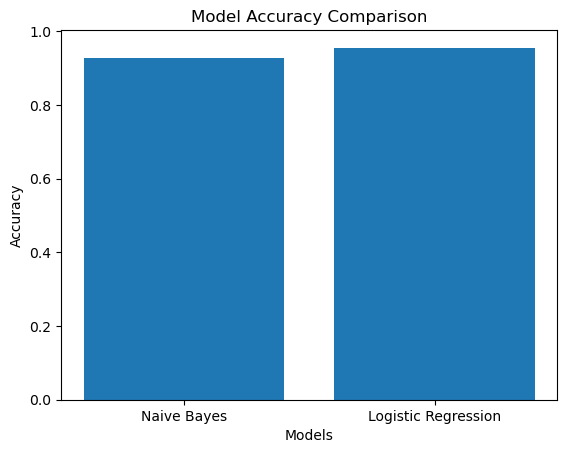

In [44]:
# Compare accuracy
score1 = nb.score(X_test_combined, y_test)
score2 = lr.score(X_test_combined, y_test)
models = ['Naive Bayes', 'Logistic Regression']
scores = [score1, score2]
plt.bar(models, scores)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()